In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('height-weight.csv')

In [5]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


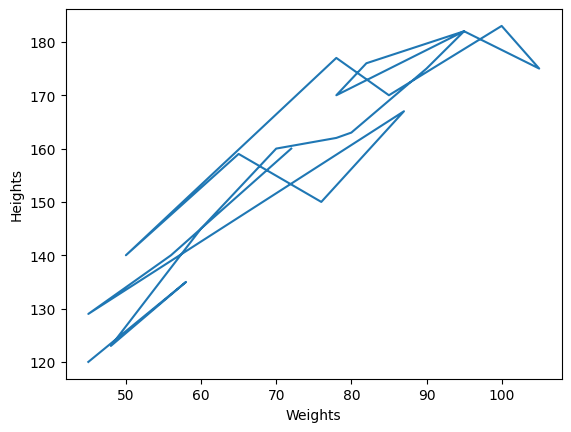

In [6]:
plt.plot(df['Weight'],df['Height'])
plt.xlabel('Weights')
plt.ylabel('Heights')
plt.show()

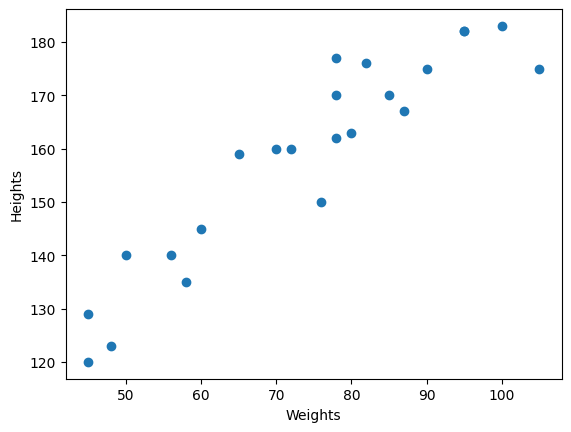

In [11]:
plt.scatter(x=df['Weight'],y=df['Height'])
plt.xlabel('Weights')
plt.ylabel('Heights')
plt.show()

In [12]:
df['Weight'].corr(df['Height'])

np.float64(0.9311418034329901)

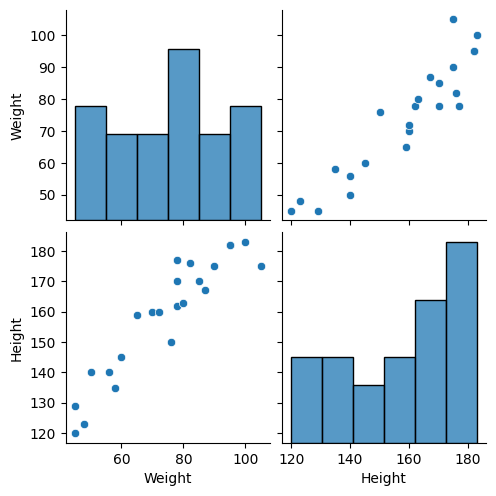

In [13]:
import seaborn as sns
sns.pairplot(df)

In [ ]:
# Independent Feature
X = df[['Weight']]
X.head() # As DataFrame or 2-D array

## Dependent Feature
y=df['Height'] # Can be a series or one dimensional array

In [18]:
y

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

In [16]:
X_series = df['Weight']
np.array(X_series).shape

(23,)

In [19]:
## Split Training and Testing Data
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [20]:
# Standarization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_train

array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [21]:
X_test = scaler.transform(X_test)
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [22]:
from sklearn.linear_model import LinearRegression

regression = LinearRegression(n_jobs=-1)

regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
print("Coefficeint or Slope",regression.coef_)
print("Intercept",regression.intercept_)

Coefficeint or Slope [17.2982057]
Intercept 156.47058823529412


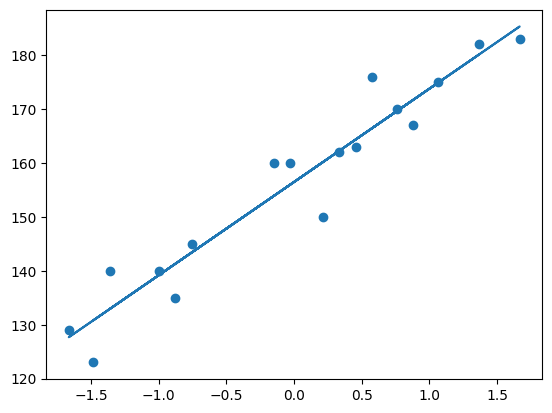

In [28]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))
plt.show()

In [29]:
y_predict = regression.predict(X_test)
y_predict

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

In [30]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

mse = mean_squared_error(y_test,y_predict)
mar = mean_absolute_error(y_test,y_predict)
msre = np.sqrt(mse)
print(mse)
print(mar)
print(msre)

114.84069295228699
9.66512588679501
10.716374991212605


In [31]:
from sklearn.metrics import r2_score
r = r2_score(y_test,y_predict)
r

0.7360826717981276

In [32]:
1-(1-r)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.6701033397476595

In [33]:
#OLS Impplementation

!pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 6.7 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.5 MB 9.0 MB/s eta 0:00:01
   ------------- -------------------------- 3.1/9.5 MB 5.6 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.5 MB 6.3 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.5 MB 5.5 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.5 MB 5.0 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.5 MB 4.8 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.5 MB 4.9 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.5 MB 4.9 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.5 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 4.4 MB/s  0:00:02

   -------------------------

In [37]:
import statsmodels.api as sm
model = sm.OLS(y_train,X_train).fit()


In [38]:
prediction = model.predict(X_test)
prediction

array([  5.79440897,   5.79440897, -28.78711691,  23.60913442,
        -7.82861638,  34.08838469])

In [39]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Fri, 17 Apr 2026   Prob (F-statistic):                       0.664
Time:                        23:42:23   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            17.2982     39.138      0.442      0.664     -65.671     100.267
==============================================================================
Omnibus:                        0.135   Durbin-Watson:                   0.002
Prob(Omnibus):                  0.935   Jarque-Bera (JB):                0.203
Skew:                          -0.166   Prob(JB):                        0.904
Kurtosis:                       2.581   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [40]:
data = [[72]]
data = scaler.transform(data)

c:\Udemy\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [41]:
regression.predict(data)

array([155.97744705])